<a href="https://colab.research.google.com/github/raki-rankawat/thesis-v1/blob/master/Model_MobileNetV2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model_MobileNetV2
Custom truncated MobileNetV2 trained from scratch on VWW.
This is the primary deployment candidate for the STM32.

In [1]:
# ── Mount Drive & load utils ────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import sys, shutil, os
UTILS_SRC = "/content/drive/My Drive/stm32-thesis/utils"
if os.path.exists(UTILS_SRC):
    shutil.copytree(UTILS_SRC, "/content/utils", dirs_exist_ok=True)
    sys.path.insert(0, "/content")
    print("✅ utils loaded from Drive")
else:
    sys.path.insert(0, "/content")
    print("⚠️  Place the utils/ folder at: My Drive/stm32-thesis/utils/")

Mounted at /content/drive
✅ utils loaded from Drive


In [2]:
# ── Imports ─────────────────────────────────────────────────────────
import os, time, random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from utils.dataset import prepare_dataset, get_loaders
from utils.models  import VWW_MobileNetV2, VWW_VGGStyle, VWW_ResNet, count_params, model_size_mb
from utils.train   import setup_device, set_seed, evaluate, train_multi_seed, plot_history

device = setup_device(seed=41)

Device: cuda


In [3]:
prepare_dataset()
train_loader, val_loader = get_loaders(batch_size=64, augmentation="standard")

1/4 Download
⬇️  Downloading VWW archive...
✅ Download complete: /content/vww_work/vw_coco2014_96.tar.gz
2/4 Extract
📦 Extracting VWW archive...
✅ Extraction complete: /content/vww_work/extracted
3/4 Find root
   Root: /content/vww_work/extracted/vw_coco2014_96
4/4 Manifests
✅ Manifests already exist: /content/drive/My Drive/vww_fixed_split_manifests
Train: 7000 | Val: 1500 | Batch: 64


In [4]:
SAVE_DIR = "/content/drive/My Drive/stm32-thesis/checkpoints"

In [5]:
results, best = train_multi_seed(
    model_fn     = VWW_MobileNetV2,
    train_loader = train_loader,
    val_loader   = val_loader,
    device       = device,
    seeds        = [41, 52, 63, 74, 85],
    save_dir     = SAVE_DIR,
    name_prefix  = "mobilenetv2",
    pretrained   = False,
    epochs          = 50,
    lr              = 1e-3,
    weight_decay    = 1e-4,
    label_smoothing = 0.1,
    patience        = 8,
)


Seed 41
Epoch   1/50 | LR 0.000999 | Train 60.29% | Val 62.67% ✅
Epoch   2/50 | LR 0.000996 | Train 63.99% | Val 65.13% ✅
Epoch   3/50 | LR 0.000991 | Train 67.97% | Val 69.13% ✅
Epoch   4/50 | LR 0.000984 | Train 69.57% | Val 69.00%
Epoch   5/50 | LR 0.000976 | Train 70.20% | Val 65.87%
Epoch   6/50 | LR 0.000965 | Train 70.76% | Val 69.13%
Epoch   7/50 | LR 0.000952 | Train 71.90% | Val 68.67%
Epoch   8/50 | LR 0.000938 | Train 71.89% | Val 73.73% ✅
Epoch   9/50 | LR 0.000922 | Train 73.10% | Val 72.67%
Epoch  10/50 | LR 0.000905 | Train 73.39% | Val 73.80% ✅
Epoch  11/50 | LR 0.000885 | Train 74.19% | Val 72.87%
Epoch  12/50 | LR 0.000864 | Train 74.13% | Val 73.80%
Epoch  13/50 | LR 0.000842 | Train 75.07% | Val 73.80%
Epoch  14/50 | LR 0.000819 | Train 75.60% | Val 74.60% ✅
Epoch  15/50 | LR 0.000794 | Train 76.47% | Val 73.20%
Epoch  16/50 | LR 0.000768 | Train 76.06% | Val 74.53%
Epoch  17/50 | LR 0.000741 | Train 76.37% | Val 73.00%
Epoch  18/50 | LR 0.000713 | Train 77.61% | 

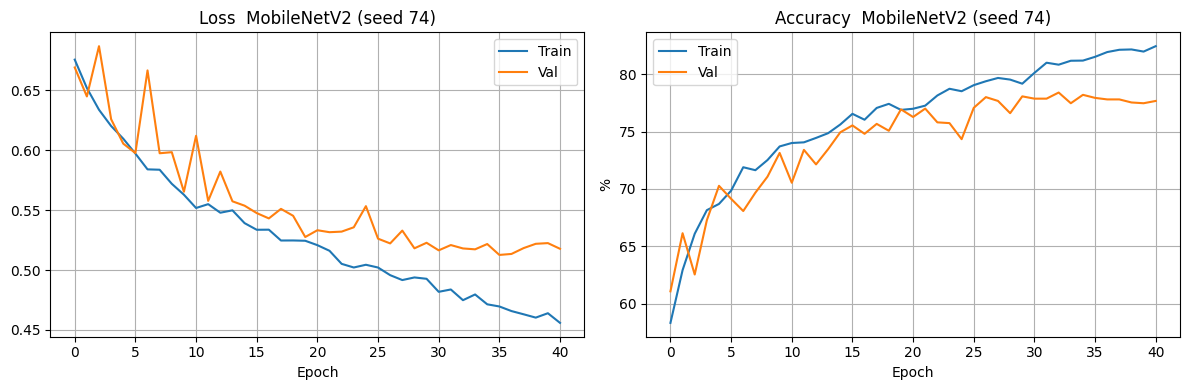

Best: 78.40% @ epoch 33  (9.4 min)

MobileNetV2  |  Mean: 77.72% ± 0.52%  |  Best: 78.40% (seed 74)
Best checkpoint: /content/drive/My Drive/stm32-thesis/checkpoints/mobilenetv2_seed_74.pth


In [6]:
plot_history(best, title=f"MobileNetV2 (seed {best['seed']})")

accs = [r["best_acc"] for r in results]
print(f"\nMobileNetV2  |  Mean: {np.mean(accs)*100:.2f}% ± {np.std(accs)*100:.2f}%  |  Best: {best['best_acc']*100:.2f}% (seed {best['seed']})")
print(f"Best checkpoint: {best['save_path']}")